# 🚀 Final Project: Tesla Stock Price Prediction using LSTM

This section contains the fully structured, step-by-step machine learning pipeline. It represents the corrected, best-practice approach to predicting time-series stock data.

### Step 1: Import Required Libraries
First, we import all necessary libraries for data manipulation, neural network creation, and visualization.

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, SimpleRNN
import warnings
warnings.filterwarnings('ignore')

### Step 2: Load and Clean Data
We load the dataset, convert the `Date` column to datetime objects, and systematically remove currency symbols from the `Open` prices so they can be processed as floats. **Crucially**, we sort the dataset chronologically (oldest to newest) to prevent look-ahead bias.

In [117]:
# Load Data
data_path = '/content/tsla_stocks.csv'
df = pd.read_csv(data_path)
df['Date'] = pd.to_datetime(df['Date'])

# Clean 'Open' prices
df['Open'] = df['Open'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

# Sort chronologically (Past -> Future)
df = df.sort_values('Date').reset_index(drop=True)

df.head()

,Date,Close/Last,Volume,Open,High,Low
0,2014-09-15,$16.924,246507477,18.2913,$18.2933,$16.6087
1,2014-09-16,$17.3827,124461748,17.0100,$17.4973,$16.828
2,2014-09-17,$17.4253,77594871,17.4940,$17.6467,$17.30
3,2014-09-18,$17.588,55342127,17.5573,$17.7067,$17.488
4,2014-09-19,$17.288,102014574,17.1993,$17.4287,$17.018


### Step 3: Feature Scaling and Time-Series Windowing
Neural networks converge faster when features are scaled. We scale the data between 0 and 1. To prevent data leakage, we `fit` the scaler **only** on the training data. We then create sequences (windows) of 50 days to predict the 51st day.

In [118]:
time_step = 50
split_ratio = 0.8

data_values = df['Open'].values.reshape(-1, 1)
train_len = int(len(data_values) * split_ratio)

train_data = data_values[:train_len]
test_data = data_values[train_len:]

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data) # Transform ONLY to prevent leakage

# Helper function to create sequences
def create_dataset(dataset, time_step):
    X, y = [], []
    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_scaled, time_step)
X_test, y_test = create_dataset(test_scaled, time_step)

# Reshape for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

actual_y_test = test_data[time_step:]
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (1963, 50, 1), y_train shape: (1963,)
X_test shape: (454, 50, 1), y_test shape: (454,)


### Step 4: Build and Train Simple RNN Model
We construct a Simple RNN network and train it for 50 epochs. Dropout layers are added to reduce overfitting.

In [119]:
epochs = 50
batch_size = 32

# Simple RNN Model
model_rnn = Sequential([
    SimpleRNN(50, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    SimpleRNN(50, activation='tanh', return_sequences=True),
    Dropout(0.2),
    SimpleRNN(50, activation='tanh', return_sequences=True),
    Dropout(0.2),
    SimpleRNN(50),
    Dropout(0.2),
    Dense(1)
])
model_rnn.compile(optimizer='adam', loss='mean_squared_error')

print("--- Training Simple RNN ---")
history_rnn = model_rnn.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)

--- Training Simple RNN ---
Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - loss: 0.4200 - val_loss: 0.0215
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1229 - val_loss: 0.0065
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0604 - val_loss: 0.0062
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0426 - val_loss: 0.0653
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0281 - val_loss: 0.0081
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0221 - val_loss: 0.0342
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0239 - val_loss: 0.0027
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0228 - val_loss: 0.0330
Epoch 9/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0168 - val_loss: 0.0026
Epoch 10/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0156 - val_loss: 0.0421
Epoch 11/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0136 - val_loss: 0.0024
Epoch 12/50
56/56 ━━━━━━━━━━━━━━━

### Step 5: Build and Train LSTM Model
Next, we construct a Long Short-Term Memory (LSTM) network and train it for 50 epochs. LSTMs generally perform better on long sequences due to their ability to remember long-term dependencies.

In [120]:
# LSTM Model
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

print("--- Training LSTM ---")
history_lstm = model_lstm.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)

--- Training LSTM ---
Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0084 - val_loss: 0.0059
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013 - val_loss: 0.0044
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012 - val_loss: 0.0059
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.1025e-04 - val_loss: 0.0036
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.3456e-04 - val_loss: 0.0081
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.7660e-04 - val_loss: 0.0053
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0010 - val_loss: 0.0029
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.6782e-04 - val_loss: 0.0031
Epoch 9/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.7150e-04 - val_loss: 0.0034
Epoch 10/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.2572e-04 - val_loss: 0.0037
Epoch 11/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.2274e-04 - val_loss: 0.0028
Epoch 12/50
5

### Step 6: Model Comparison - Evaluation Metrics
Now that both models are trained, we generate predictions on the unseen test set and compare their performance side-by-side using standard regression metrics.

In [121]:
# Predictions
pred_rnn_scaled = model_rnn.predict(X_test)
pred_rnn = scaler.inverse_transform(pred_rnn_scaled)

pred_lstm_scaled = model_lstm.predict(X_test)
pred_lstm = scaler.inverse_transform(pred_lstm_scaled)

# Evaluation Function
def evaluate_model(name, actual, predicted):
    mse = mean_squared_error(actual, predicted)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    print(f"--- {name} Evaluation ---")
    print(f"MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R-Squared: {r2:.4f}\n")

evaluate_model("Simple RNN", actual_y_test, pred_rnn)
evaluate_model("LSTM", actual_y_test, pred_lstm)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
--- Simple RNN Evaluation ---
MSE: 294.4539 | RMSE: 17.1597 | MAE: 14.5263 | R-Squared: 0.8057

--- LSTM Evaluation ---
MSE: 210.3202 | RMSE: 14.5024 | MAE: 12.0001 | R-Squared: 0.8612



### Step 7: Model Comparison - Visualizations
Finally, we plot the training loss curves to see how well each model converged, and overlay their final price predictions against the actual test data.

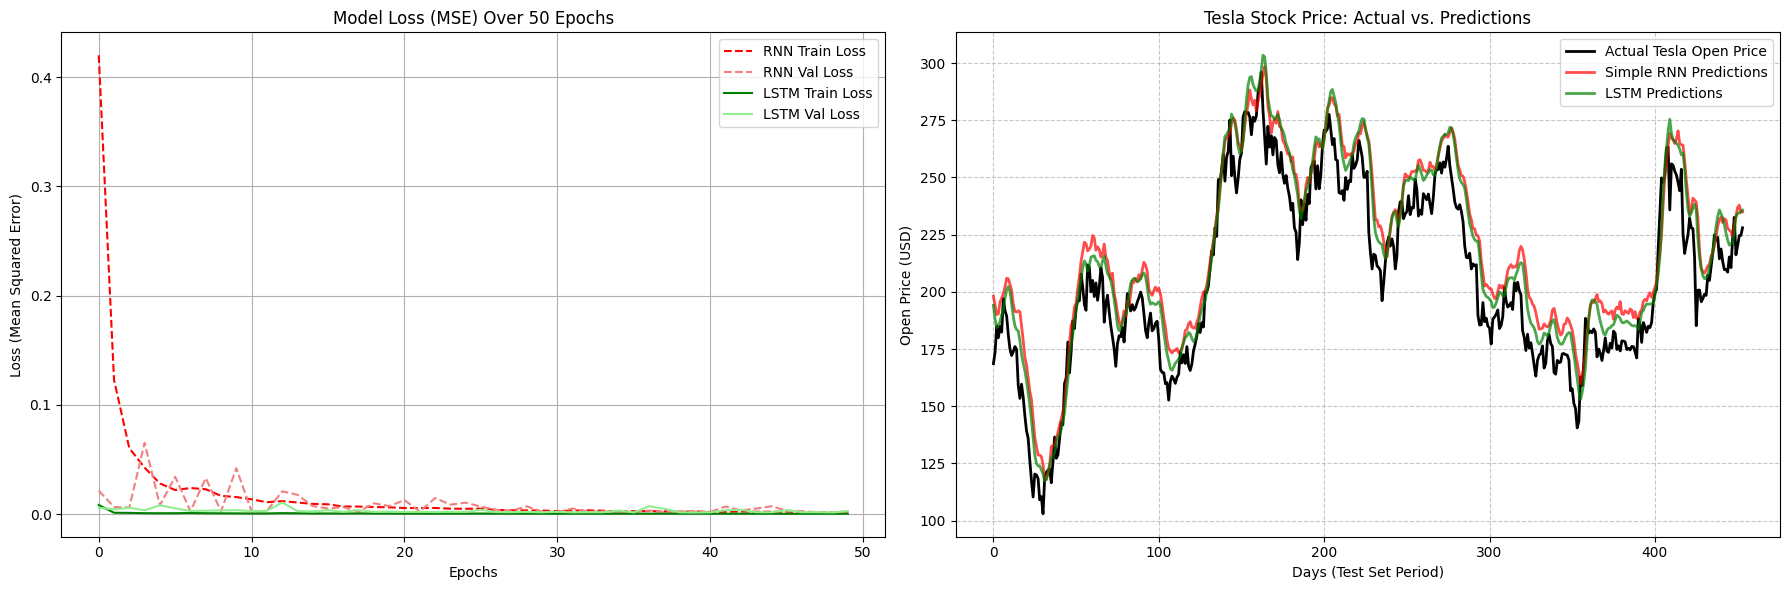

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Training & Validation Loss
axes[0].plot(history_rnn.history['loss'], label='RNN Train Loss', color='red', linestyle='--')
axes[0].plot(history_rnn.history['val_loss'], label='RNN Val Loss', color='lightcoral', linestyle='--')
axes[0].plot(history_lstm.history['loss'], label='LSTM Train Loss', color='green')
axes[0].plot(history_lstm.history['val_loss'], label='LSTM Val Loss', color='lightgreen')
axes[0].set_title('Model Loss (MSE) Over 50 Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss (Mean Squared Error)')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Actual vs Predicted Prices
axes[1].plot(actual_y_test, color='black', label='Actual Tesla Open Price', linewidth=2)
axes[1].plot(pred_rnn, color='red', label='Simple RNN Predictions', alpha=0.7, linewidth=2)
axes[1].plot(pred_lstm, color='green', label='LSTM Predictions', alpha=0.7, linewidth=2)
axes[1].set_title('Tesla Stock Price: Actual vs. Predictions')
axes[1].set_xlabel('Days (Test Set Period)')
axes[1].set_ylabel('Open Price (USD)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()